In [53]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table
from rich.box import ROUNDED
from scipy import stats
from rich.panel import Panel
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# style settings 
plt.rcParams['font.family'] = 'Times New Roman'

In [3]:
# load the dataset
data = pd.read_csv('personality_fit_dataset.csv')

In [4]:
# display random sample of the dataset
data.sample(5)

,employee_id,department,manager_leadership_style,pers_openness,pers_conscientiousness,pers_extraversion,pers_agreeableness,pers_neuroticism,work_flexibility_preference,years_at_company,p_o_fit_score,fit_eligibility_class
6006,EMP_06007,Engineering,Democratic,3.28,3.68,3.20,3.95,2.61,4,5.5,43.7,Low
8851,EMP_08852,Product Management,Supportive,3.93,3.66,2.73,3.56,2.86,3,1.4,52.3,Moderate
4737,EMP_04738,Engineering,Democratic,2.37,4.62,3.25,3.36,1.76,5,1.2,52.7,Moderate
2797,EMP_02798,Engineering,Supportive,4.74,3.85,2.88,4.03,3.35,4,1.4,53.7,Moderate
5799,EMP_05800,Data Science,Supportive,3.92,4.18,2.91,4.12,1.93,1,6.5,54.2,Moderate


In [5]:
import importlib
import classes.data_info_display 

importlib.reload(classes.data_info_display)

from classes.data_info_display import DataInfoDisplay
print("✅ Class successfully reloaded")

✅ Class successfully reloaded


In [6]:
# display data information using the DataInfoDisplay class
data_display = DataInfoDisplay(data=data)   
data_display.display()

                                 Data Info                                 
╭─────────────────────────────┬──────────┬────────┬─────────┬─────────────╮
│ Column                      │ Non-Null │ Unique │  Dtype  │ Sample      │
├─────────────────────────────┼──────────┼────────┼─────────┼─────────────┤
│ employee_id                 │  10,000  │ 10,000 │ object  │ EMP_00001   │
│ department                  │  10,000  │   6    │ object  │ Engineering │
│ manager_leadership_style    │  10,000  │   3    │ object  │ Democratic  │
│ pers_openness               │  10,000  │  317   │ float64 │ 3.68        │
│ pers_conscientiousness      │  10,000  │  264   │ float64 │ 4.54        │
│ pers_extraversion           │  10,000  │  387   │ float64 │ 4.23        │
│ pers_agreeableness          │  10,000  │  332   │ float64 │ 3.73        │
│ pers_neuroticism            │  10,000  │  379   │ float64 │ 1.86        │
│ work_flexibility_preference │  10,000  │   5    │  int64  │ 3           │
│ years_at_company            │  10,000  │  193   │ float64 │ 2.4         │
│ p_o_fit_score               │  10,000  │  675   │ float64 │ 59.8        │
│ fit_eligibility_class       │  10,000  │   3    │ object  │ Moderate    │
╰─────────────────────────────┴──────────┴────────┴─────────┴─────────────╯
                               Memory: 2.84 MB                             

  ➤ Rows          10,000  
  ➤ Columns           12  

In [ ]:
console = Console()

def display_value_counts(data: pd.DataFrame, columns: list, top_n: int = 10):
    """
    Display beautiful and professional value counts for selected columns.
    """
    for col in columns:
        if col not in data.columns:
            console.print(f"[red]Column '{col}' not found![/red]")
            continue
            
        vc = data[col].value_counts().head(top_n)
        total = len(data)
        percentages = (vc / total * 100).round(2)

        # Create beautiful table
        table = Table(
            title=f"🔢 Value Counts - {col.replace('_', ' ').title()}",
            title_style="bold #6A5ACD",
            box=ROUNDED,
            header_style="bold #6A5ACD",
            show_lines=True
        )

        table.add_column("Rank", justify="center", style="dim", width=6)
        table.add_column("Value", style="bold cyan", no_wrap=True)
        table.add_column("Count", justify="right", style="bold")
        table.add_column("Percentage", justify="right", style="bold green")
        table.add_column("Bar", justify="left", width=35)

        for i, (value, count) in enumerate(vc.items(), 1):
            pct = percentages.iloc[i-1]      # Corrected indexing for percentages
            bar_length = int(pct / 3)
            bar = "█" * bar_length + "░" * (30 - bar_length)
            
            table.add_row(
                f"#{i}",
                str(value),
                f"{count:,}",
                f"{pct}%",
                f"[#7B68EE]{bar}[/#7B68EE]"
            )

        console.print(table)
        console.print()   # Add space between tables


display_value_counts(
    data=data, 
    columns=['department', 'manager_leadership_style'],
    top_n=12
)

                               🔢 Value Counts - Department                               
╭────────┬────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│  Rank  │ Value              │ Count │ Percentage │ Bar                                 │
├────────┼────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│   #1   │ Engineering        │ 2,960 │      29.6% │ █████████░░░░░░░░░░░░░░░░░░░░░      │
├────────┼────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│   #2   │ Sales              │ 2,061 │     20.61% │ ██████░░░░░░░░░░░░░░░░░░░░░░░░      │
├────────┼────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│   #3   │ Marketing          │ 1,504 │     15.04% │ █████░░░░░░░░░░░░░░░░░░░░░░░░░      │
├────────┼────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│   #4   │ Data Science       │ 1,465 │     14.65% │ ████░░░░░░░░░░░░░░░░░░░░░░░░░░      │
├────────┼────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│   #5   │ Product Management │ 1,199 │     11.99% │ ███░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
├────────┼────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│   #6   │ HR                 │   811 │      8.11% │ ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
╰────────┴────────────────────┴───────┴────────────┴─────────────────────────────────────╯

                            🔢 Value Counts - Manager Leadership Style                            
╭────────┬────────────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│  Rank  │ Value                      │ Count │ Percentage │ Bar                                 │
├────────┼────────────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│   #1   │ Supportive                 │ 4,420 │      44.2% │ ██████████████░░░░░░░░░░░░░░░░      │
├────────┼────────────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│   #2   │ Democratic                 │ 3,585 │     35.85% │ ███████████░░░░░░░░░░░░░░░░░░░      │
├────────┼────────────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│   #3   │ Autocratic/Micromanagement │ 1,995 │     19.95% │ ██████░░░░░░░░░░░░░░░░░░░░░░░░      │
╰────────┴────────────────────────────┴───────┴────────────┴─────────────────────────────────────╯

### Big Five Personality Traits

<div class="pd-index-animation">
     Openness to Experience
</div>
<style>
.pd-index-animation {
  font-family: 'Courier New', monospace;
  font-size: 1.8em;
  color: rgb(156, 174, 212); /* رنگ مشابه تم pandas در VS Code */
  background: #1e1e1e;
  padding: 16px 20px;
  border-radius: 8px;
  display: inline-block;
  opacity: 0;
  transform: scale(0.8);
  animation: fadeInScale 1.2s cubic-bezier(0.34, 1.56, 0.64, 1) forwards;
  letter-spacing: 1px;
}
@keyframes fadeInScale {
  to {
    opacity: 1;
    transform: scale(1);
  }
}
</style>

In [9]:
def plot_professional_scatter(data, x_col, y_col, figsize=(13, 7)):
    """
    Professional scatter plot with linear + non-linear trend lines and statistics.
    """
    plt.figure(figsize=figsize)
    
    # Main regression plot
    ax = sns.regplot(
        x=x_col, 
        y=y_col, 
        data=data,
        scatter_kws={
            'alpha': 0.65, 
            's': 45, 
            'color': '#5E7AC2',
            'edgecolor': 'white',
            'linewidths': 0.8       
        },
        line_kws={
            'color': '#E74C3C', 
            'linewidth': 2.8,
            'label': 'Linear Regression'
        },
        ci=95,
        scatter=True
    )
    
    # Non-linear trend (LOWESS)
    sns.regplot(
        x=x_col, 
        y=y_col, 
        data=data,
        scatter=False,
        line_kws={'color': '#27AE60', 'linewidth': 2.2, 'linestyle': '--'},
        lowess=True,
        label='LOWESS (Non-linear Trend)'
    )
    
    # Calculate Pearson correlation and p-value
    corr, p_value = stats.pearsonr(data[x_col].dropna(), data[y_col].dropna())
    
    # Title and info box
    plt.title(f'Correlation between {x_col.replace("_", " ").title()} and {y_col.replace("_", " ").title()}', 
              fontsize=15, fontweight='bold', pad=20)
    
    info_text = f"Pearson r  = {corr:.3f}\np-value   = {p_value:.4f}"
    plt.gca().text(0.05, 0.95, info_text, transform=plt.gca().transAxes,
                   bbox=dict(boxstyle="round,pad=0.7", facecolor="white", edgecolor="#2C3E50", alpha=0.95),
                   fontsize=11.5, verticalalignment='top')
    
    # Labels
    plt.xlabel(x_col.replace('_', ' ').title(), fontsize=13)
    plt.ylabel(y_col.replace('_', ' ').title(), fontsize=13)
    
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()

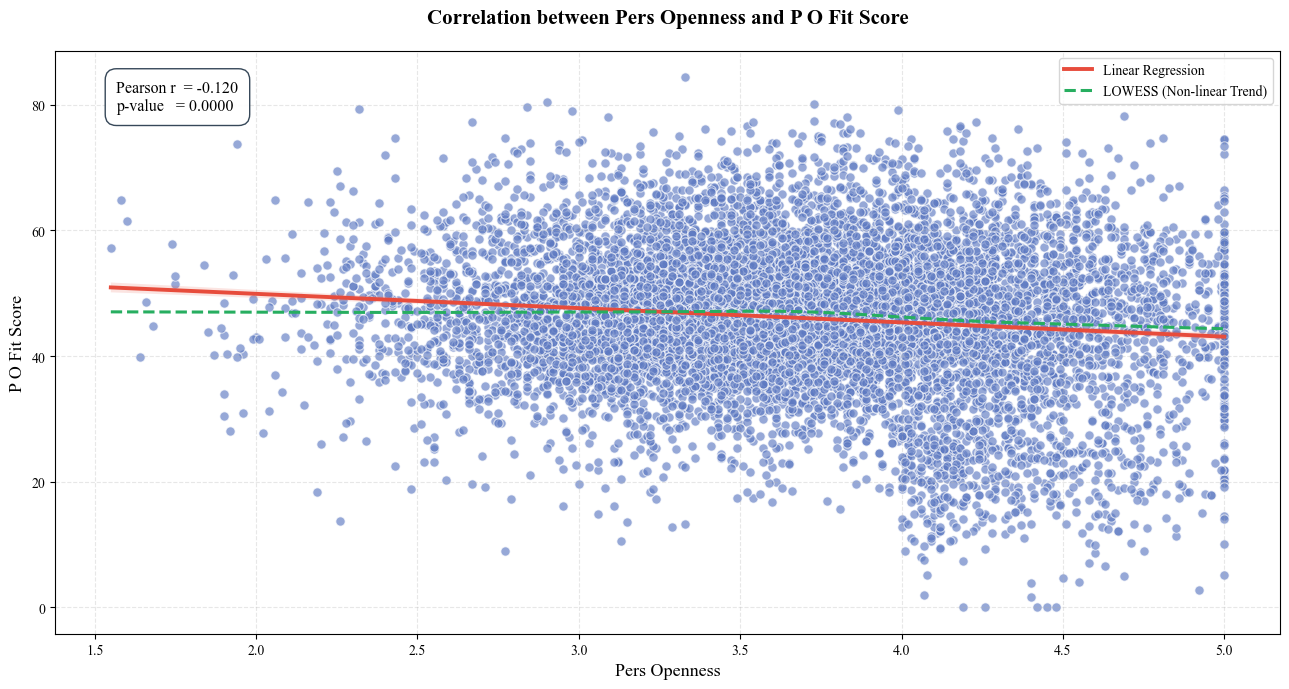

In [10]:
plot_professional_scatter(
    data=data, 
    x_col='pers_openness', 
    y_col='p_o_fit_score'
)

In [ ]:
console = Console()

def analyze_high_openness_low_fit(
    data, 
    openness_threshold: float = 4.0, 
    fit_score_threshold: float = 35.0
):
    """
    Analyze employees with High Openness but Low P-O Fit Score
    """
    # Filter the data with dynamic thresholds
    filtered = data[
        (data['p_o_fit_score'] <= fit_score_threshold) & 
        (data['pers_openness'] > openness_threshold)
    ]
    
    total_filtered = len(filtered)
    total_original = len(data)
    percentage = (total_filtered / total_original * 100) if total_original > 0 else 0

    # Dynamic Header
    console.print(Panel(
        f"[bold #E74C3C]High Openness + Low P-O Fit Analysis[/bold #E74C3C]\n"
        f"Criteria → Openness > {openness_threshold}  |  P-O Fit Score ≤ {fit_score_threshold}\n"
        f"Total Employees: [bold]{total_filtered}[/bold]  "
        f"([bold]{percentage:.1f}%[/bold] of dataset)",
        title="📊 FILTERED GROUP",
        border_style="#E74C3C"
    ))

    # Inner function to create percentage tables
    def print_percentage_table(column_name: str, title: str):
        if column_name not in filtered.columns:
            console.print(f"[red]Column '{column_name}' not found![/red]")
            return
            
        vc = filtered[column_name].value_counts()
        percentages = (vc / total_filtered * 100).round(2)
        
        table = Table(
            title=title,
            title_style="bold #6A5ACD",
            box=ROUNDED,
            header_style="bold #6A5ACD"
        )
        
        table.add_column("Category", style="bold", no_wrap=True)
        table.add_column("Count", justify="right")
        table.add_column("Percentage", justify="right")
        table.add_column("Bar", justify="left", width=35)
        
        for value, count in vc.items():
            pct = percentages[value]
            bar = "█" * int(pct / 3) + "░" * (30 - int(pct / 3))
            
            table.add_row(
                str(value),
                f"{count:,}",
                f"{pct}%",
                f"[#5E7AC2]{bar}[/#5E7AC2]"
            )
        
        console.print(table)
        console.print()

    # Display results
    print_percentage_table(
        'manager_leadership_style', 
        "🔹 Management Leadership Style Distribution"
    )
    
    print_percentage_table(
        'department', 
        "🔹 Department Distribution"
    )

In [32]:
analyze_high_openness_low_fit(data)

╭─────────────────────────────────────────────── 📊 FILTERED GROUP ───────────────────────────────────────────────╮
│ High Openness + Low P-O Fit Analysis                                                                            │
│ Criteria → Openness > 4.0  |  P-O Fit Score ≤ 35.0                                                              │
│ Total Employees: 766  (7.7% of dataset)                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                       🔹 Management Leadership Style Distribution                       
╭────────────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│ Category                   │ Count │ Percentage │ Bar                                 │
├────────────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│ Autocratic/Micromanagement │   556 │     72.58% │ ████████████████████████░░░░░░      │
│ Democratic                 │   169 │     22.06% │ ███████░░░░░░░░░░░░░░░░░░░░░░░      │
│ Supportive                 │    41 │      5.35% │ █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
╰────────────────────────────┴───────┴────────────┴─────────────────────────────────────╯

                           🔹 Department Distribution                            
╭────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│ Category           │ Count │ Percentage │ Bar                                 │
├────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│ Sales              │   218 │     28.46% │ █████████░░░░░░░░░░░░░░░░░░░░░      │
│ Engineering        │   204 │     26.63% │ ████████░░░░░░░░░░░░░░░░░░░░░░      │
│ Marketing          │   107 │     13.97% │ ████░░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Product Management │    89 │     11.62% │ ███░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Data Science       │    88 │     11.49% │ ███░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ HR                 │    60 │      7.83% │ ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
╰────────────────────┴───────┴────────────┴─────────────────────────────────────╯

In [31]:
analyze_high_openness_low_fit(
    data=data,
    openness_threshold=4.5,
    fit_score_threshold=30
)

╭─────────────────────────────────────────────── 📊 FILTERED GROUP ───────────────────────────────────────────────╮
│ High Openness + Low P-O Fit Analysis                                                                            │
│ Criteria → Openness > 4.5  |  P-O Fit Score ≤ 30                                                                │
│ Total Employees: 164  (1.6% of dataset)                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                       🔹 Management Leadership Style Distribution                       
╭────────────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│ Category                   │ Count │ Percentage │ Bar                                 │
├────────────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│ Autocratic/Micromanagement │   142 │     86.59% │ ████████████████████████████░░      │
│ Democratic                 │    17 │     10.37% │ ███░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Supportive                 │     5 │      3.05% │ █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
╰────────────────────────────┴───────┴────────────┴─────────────────────────────────────╯

                           🔹 Department Distribution                            
╭────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│ Category           │ Count │ Percentage │ Bar                                 │
├────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│ Sales              │    51 │      31.1% │ ██████████░░░░░░░░░░░░░░░░░░░░      │
│ Engineering        │    47 │     28.66% │ █████████░░░░░░░░░░░░░░░░░░░░░      │
│ Data Science       │    22 │     13.41% │ ████░░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Product Management │    17 │     10.37% │ ███░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Marketing          │    16 │      9.76% │ ███░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ HR                 │    11 │      6.71% │ ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
╰────────────────────┴───────┴────────────┴─────────────────────────────────────╯

<div class="pd-index-animation">
     Conscientiousness
</div>
<style>
.pd-index-animation {
  font-family: 'Courier New', monospace;
  font-size: 1.8em;
  color: rgb(156, 174, 212); /* رنگ مشابه تم pandas در VS Code */
  background: #1e1e1e;
  padding: 16px 20px;
  border-radius: 8px;
  display: inline-block;
  opacity: 0;
  transform: scale(0.8);
  animation: fadeInScale 1.2s cubic-bezier(0.34, 1.56, 0.64, 1) forwards;
  letter-spacing: 1px;
}
@keyframes fadeInScale {
  to {
    opacity: 1;
    transform: scale(1);
  }
}
</style>

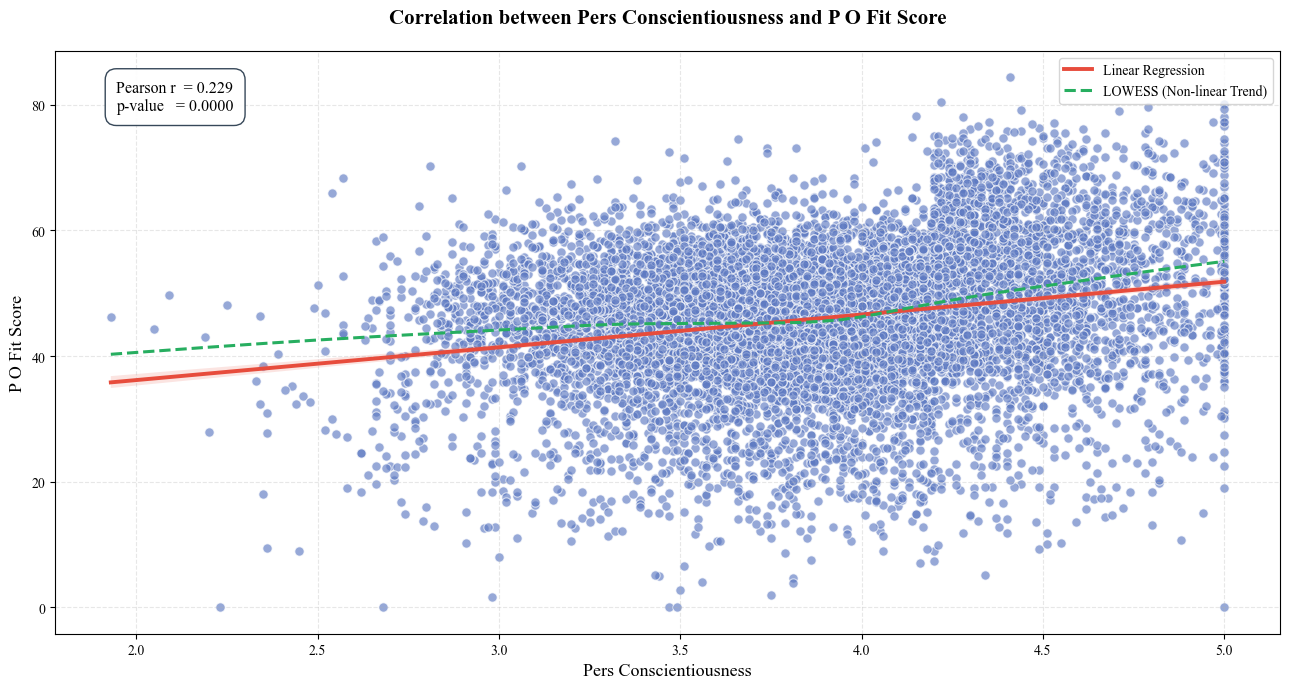

In [12]:
plot_professional_scatter(
    data=data, 
    x_col='pers_conscientiousness', 
    y_col='p_o_fit_score'
)

In [34]:
data.sample()

,employee_id,department,manager_leadership_style,pers_openness,pers_conscientiousness,pers_extraversion,pers_agreeableness,pers_neuroticism,work_flexibility_preference,years_at_company,p_o_fit_score,fit_eligibility_class
7824,EMP_07825,Data Science,Supportive,2.75,5.0,4.2,3.45,3.18,5,0.5,59.6,Moderate


In [ ]:
def analyze_low_conscientiousness_low_fit(
    data, 
    conscientiousness_threshold: float = 2.8, 
    fit_score_threshold: float = 40.0
):
    """
    Analyze employees with Low Conscientiousness and Low P-O Fit Score
    to understand which departments or leadership styles fail to accommodate them.
    """
    # Filter the data: looking for low discipline/organization that leads to low fit
    filtered = data[
        (data['p_o_fit_score'] <= fit_score_threshold) & 
        (data['pers_conscientiousness'] < conscientiousness_threshold)
    ]
    
    total_filtered = len(filtered)
    total_original = len(data)
    percentage = (total_filtered / total_original * 100) if total_original > 0 else 0

    # Dynamic Header using Rich Panel
    console.print(Panel(
        f"[bold #D35400]Low Conscientiousness + Low P-O Fit Analysis[/bold #D35400]\n"
        f"Criteria → Conscientiousness < {conscientiousness_threshold}  |  P-O Fit Score ≤ {fit_score_threshold}\n"
        f"Total Vulnerable Employees: [bold]{total_filtered}[/bold]  "
        f"([bold]{percentage:.1f}%[/bold] of dataset)",
        title="⚠️ RISK ASSESSMENT GROUP",
        border_style="#D35400"
    ))

    # Inner function to generate the Rich tables with horizontal bars
    def print_percentage_table(column_name: str, title: str):
        if column_name not in filtered.columns:
            console.print(f"[red]Column '{column_name}' not found![/red]")
            return
            
        vc = filtered[column_name].value_counts()
        percentages = (vc / total_filtered * 100).round(2)
        
        table = Table(
            title=title,
            title_style="bold #16A085",
            box=ROUNDED,
            header_style="bold #16A085"
        )
        
        table.add_column("Category", style="bold", no_wrap=True)
        table.add_column("Count", justify="right")
        table.add_column("Percentage", justify="right")
        table.add_column("Bar (Visual)", justify="left", width=35)
        
        for value, count in vc.items():
            pct = percentages[value]
            bar = "█" * int(pct / 3) + "░" * (30 - int(pct / 3))
            
            table.add_row(
                str(value),
                f"{count:,}",
                f"{pct}%",
                f"[#E67E22]{bar}[/#E67E22]"
            )
        
        console.print(table)
        console.print()

    # Display results for Department first (Crucial for Conscientiousness)
    print_percentage_table(
        'department', 
        "🔹 Department Distribution (Where does Low Discipline cause the most damage?)"
    )
    
    # Display results for Leadership Style
    print_percentage_table(
        'manager_leadership_style', 
        "🔹 Management Leadership Style Distribution"
    )

 
analyze_low_conscientiousness_low_fit(data)

analyze_low_conscientiousness_low_fit(
    data=data,
    conscientiousness_threshold=3.0,
    fit_score_threshold=50.0
)

╭──────────────────────────────────────────── ⚠️ RISK ASSESSMENT GROUP ────────────────────────────────────────────╮
│ Low Conscientiousness + Low P-O Fit Analysis                                                                    │
│ Criteria → Conscientiousness < 2.8  |  P-O Fit Score ≤ 40.0                                                     │
│ Total Vulnerable Employees: 76  (0.8% of dataset)                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

  🔹 Department Distribution (Where does Low Discipline cause the most damage?)  
╭────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│ Category           │ Count │ Percentage │ Bar (Visual)                        │
├────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│ Engineering        │    43 │     56.58% │ ██████████████████░░░░░░░░░░░░      │
│ Sales              │    12 │     15.79% │ █████░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Data Science       │    12 │     15.79% │ █████░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Marketing          │     5 │      6.58% │ ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Product Management │     2 │      2.63% │ ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ HR                 │     2 │      2.63% │ ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
╰────────────────────┴───────┴────────────┴─────────────────────────────────────╯

                       🔹 Management Leadership Style Distribution                       
╭────────────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│ Category                   │ Count │ Percentage │ Bar (Visual)                        │
├────────────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│ Democratic                 │    33 │     43.42% │ ██████████████░░░░░░░░░░░░░░░░      │
│ Supportive                 │    24 │     31.58% │ ██████████░░░░░░░░░░░░░░░░░░░░      │
│ Autocratic/Micromanagement │    19 │      25.0% │ ████████░░░░░░░░░░░░░░░░░░░░░░      │
╰────────────────────────────┴───────┴────────────┴─────────────────────────────────────╯

╭──────────────────────────────────────────── ⚠️ RISK ASSESSMENT GROUP ────────────────────────────────────────────╮
│ Low Conscientiousness + Low P-O Fit Analysis                                                                    │
│ Criteria → Conscientiousness < 3.0  |  P-O Fit Score ≤ 50.0                                                     │
│ Total Vulnerable Employees: 290  (2.9% of dataset)                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

  🔹 Department Distribution (Where does Low Discipline cause the most damage?)  
╭────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│ Category           │ Count │ Percentage │ Bar (Visual)                        │
├────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│ Engineering        │   100 │     34.48% │ ███████████░░░░░░░░░░░░░░░░░░░      │
│ Sales              │    52 │     17.93% │ █████░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Marketing          │    44 │     15.17% │ █████░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Product Management │    35 │     12.07% │ ████░░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Data Science       │    33 │     11.38% │ ███░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ HR                 │    26 │      8.97% │ ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
╰────────────────────┴───────┴────────────┴─────────────────────────────────────╯

                       🔹 Management Leadership Style Distribution                       
╭────────────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│ Category                   │ Count │ Percentage │ Bar (Visual)                        │
├────────────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│ Democratic                 │   112 │     38.62% │ ████████████░░░░░░░░░░░░░░░░░░      │
│ Supportive                 │   104 │     35.86% │ ███████████░░░░░░░░░░░░░░░░░░░      │
│ Autocratic/Micromanagement │    74 │     25.52% │ ████████░░░░░░░░░░░░░░░░░░░░░░      │
╰────────────────────────────┴───────┴────────────┴─────────────────────────────────────╯

<div class="pd-index-animation">
     Extraversion
</div>
<style>
.pd-index-animation {
  font-family: 'Courier New', monospace;
  font-size: 1.8em;
  color: rgb(156, 174, 212); /* رنگ مشابه تم pandas در VS Code */
  background: #1e1e1e;
  padding: 16px 20px;
  border-radius: 8px;
  display: inline-block;
  opacity: 0;
  transform: scale(0.8);
  animation: fadeInScale 1.2s cubic-bezier(0.34, 1.56, 0.64, 1) forwards;
  letter-spacing: 1px;
}
@keyframes fadeInScale {
  to {
    opacity: 1;
    transform: scale(1);
  }
}
</style>

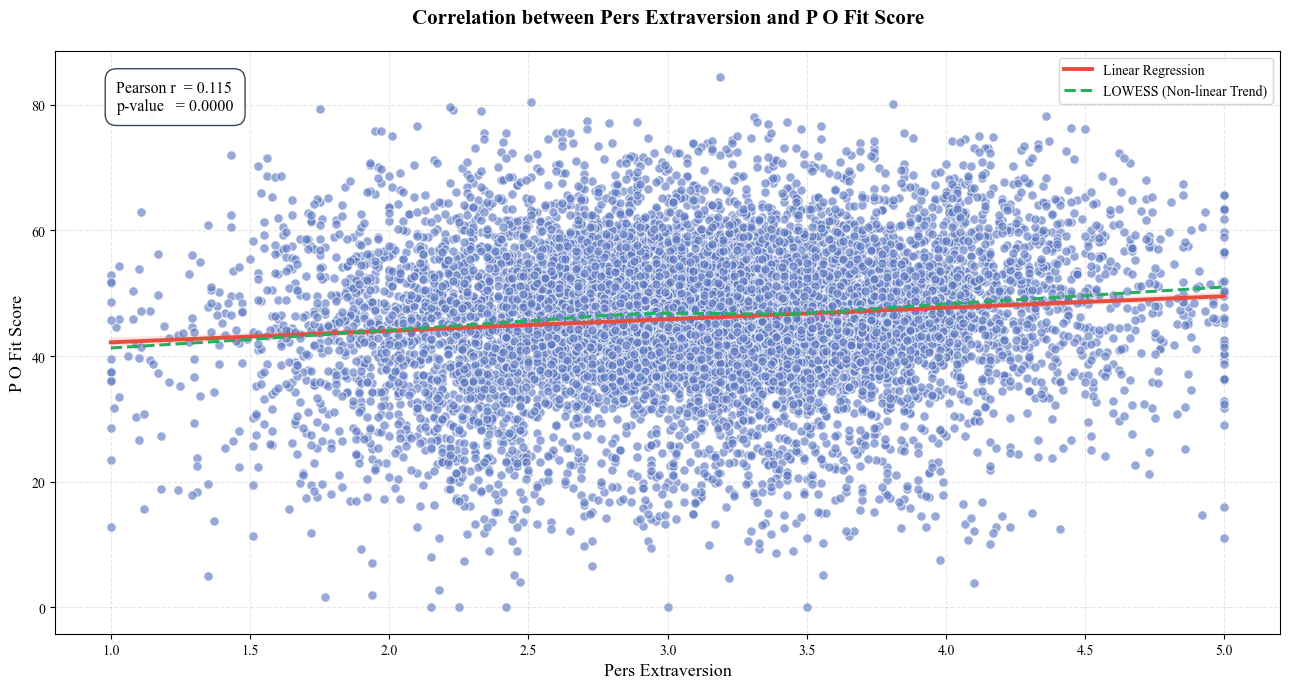

In [13]:
plot_professional_scatter(
    data=data, 
    x_col='pers_extraversion', 
    y_col='p_o_fit_score'
)

In [38]:
def analyze_extraversion_mismatch(
    data, 
    extraversion_threshold: float = 2.5, 
    fit_score_threshold: float = 45.0
):
    """
    Analyze Introverted employees (Low Extraversion) placed in communicative roles 
    like Sales and Marketing who suffer from Low P-O Fit Scores.
    """
    # Filter for Introverts placed in Sales/Marketing with Low Fit
    filtered = data[
        (data['p_o_fit_score'] <= fit_score_threshold) & 
        (data['pers_extraversion'] < extraversion_threshold) &
        (data['department'].isin(['Sales', 'Marketing']))
    ]
    
    total_filtered = len(filtered)
    total_original = len(data)
    percentage = (total_filtered / total_original * 100) if total_original > 0 else 0

    # Dynamic Header using Rich Panel
    console.print(Panel(
        f"[bold #2980B9]Introversion Mismatch Analysis (Sales & Marketing)[/bold #2980B9]\n"
        f"Criteria → Extraversion < {extraversion_threshold}  |  Department in [Sales, Marketing]  |  Fit Score ≤ {fit_score_threshold}\n"
        f"Total Mismatched Employees: [bold]{total_filtered}[/bold]  "
        f"([bold]{percentage:.1f}%[/bold] of dataset)",
        title="📢 TALENT MISALIGNMENT REPORT",
        border_style="#2980B9"
    ))

    # Inner function to generate the Rich tables
    def print_percentage_table(column_name: str, title: str):
        if column_name not in filtered.columns:
            console.print(f"[red]Column '{column_name}' not found![/red]")
            return
            
        vc = filtered[column_name].value_counts()
        percentages = (vc / total_filtered * 100).round(2)
        
        table = Table(
            title=title,
            title_style="bold #8E44AD",
            box=ROUNDED,
            header_style="bold #8E44AD"
        )
        
        table.add_column("Category", style="bold", no_wrap=True)
        table.add_column("Count", justify="right")
        table.add_column("Percentage", justify="right")
        table.add_column("Bar (Visual)", justify="left", width=35)
        
        for value, count in vc.items():
            pct = percentages[value]
            bar = "█" * int(pct / 3) + "░" * (30 - int(pct / 3))
            
            table.add_row(
                str(value),
                f"{count:,}",
                f"{pct}%",
                f"[#3498DB]{bar}[/#3498DB]"
            )
        
        console.print(table)
        console.print()

    # Display results for Department (To see the split between Sales and Marketing)
    print_percentage_table(
        'department', 
        "🔹 Department Distribution (Where is Introversion causing the low fit?)"
    )
    
    # Display results for Leadership Style
    print_percentage_table(
        'manager_leadership_style', 
        "🔹 Management Leadership Style for these Mismatched Employees"
    )

analyze_extraversion_mismatch(data)

╭───────────────────────────────────────── 📢 TALENT MISALIGNMENT REPORT ─────────────────────────────────────────╮
│ Introversion Mismatch Analysis (Sales & Marketing)                                                              │
│ Criteria → Extraversion < 2.5  |  Department in [Sales, Marketing]  |  Fit Score ≤ 45.0                         │
│ Total Mismatched Employees: 546  (5.5% of dataset)                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

🔹 Department Distribution (Where is Introversion causing the low fit?) 
╭───────────┬───────┬────────────┬─────────────────────────────────────╮
│ Category  │ Count │ Percentage │ Bar (Visual)                        │
├───────────┼───────┼────────────┼─────────────────────────────────────┤
│ Sales     │   408 │     74.73% │ ████████████████████████░░░░░░      │
│ Marketing │   138 │     25.27% │ ████████░░░░░░░░░░░░░░░░░░░░░░      │
╰───────────┴───────┴────────────┴─────────────────────────────────────╯

              🔹 Management Leadership Style for these Mismatched Employees              
╭────────────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│ Category                   │ Count │ Percentage │ Bar (Visual)                        │
├────────────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│ Democratic                 │   236 │     43.22% │ ██████████████░░░░░░░░░░░░░░░░      │
│ Supportive                 │   198 │     36.26% │ ████████████░░░░░░░░░░░░░░░░░░      │
│ Autocratic/Micromanagement │   112 │     20.51% │ ██████░░░░░░░░░░░░░░░░░░░░░░░░      │
╰────────────────────────────┴───────┴────────────┴─────────────────────────────────────╯

<Figure size 1200x600 with 0 Axes>

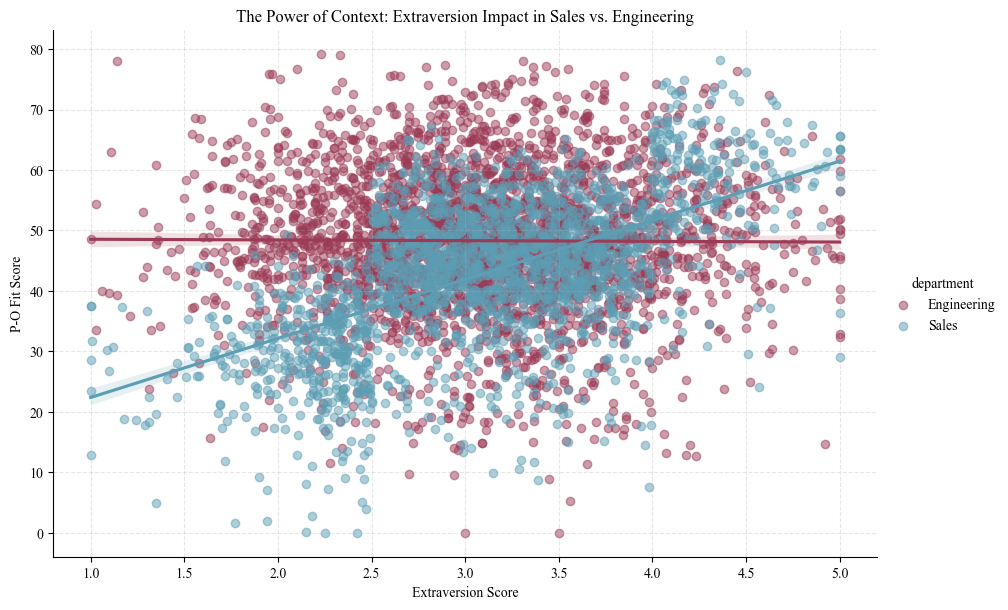

In [ ]:
comparison_df = data[data['department'].isin(['Sales', 'Engineering'])]

plt.figure(figsize=(12, 6))
sns.lmplot(
    data=comparison_df,
    x='pers_extraversion',
    y='p_o_fit_score',
    hue='department',
    palette={'Sales': "#5C9EB4", 'Engineering': "#9B3B56"},
    height=6,
    aspect=1.5,
    scatter_kws={'alpha': 0.5}
)

plt.title('The Power of Context: Extraversion Impact in Sales vs. Engineering')
plt.xlabel('Extraversion Score')
plt.ylabel('P-O Fit Score')
plt.grid(True, alpha=0.3, linestyle='--')
plt.show();

<div class="pd-index-animation">
     Agreeableness
</div>
<style>
.pd-index-animation {
  font-family: 'Courier New', monospace;
  font-size: 1.8em;
  color: rgb(156, 174, 212); /* رنگ مشابه تم pandas در VS Code */
  background: #1e1e1e;
  padding: 16px 20px;
  border-radius: 8px;
  display: inline-block;
  opacity: 0;
  transform: scale(0.8);
  animation: fadeInScale 1.2s cubic-bezier(0.34, 1.56, 0.64, 1) forwards;
  letter-spacing: 1px;
}
@keyframes fadeInScale {
  to {
    opacity: 1;
    transform: scale(1);
  }
}
</style>

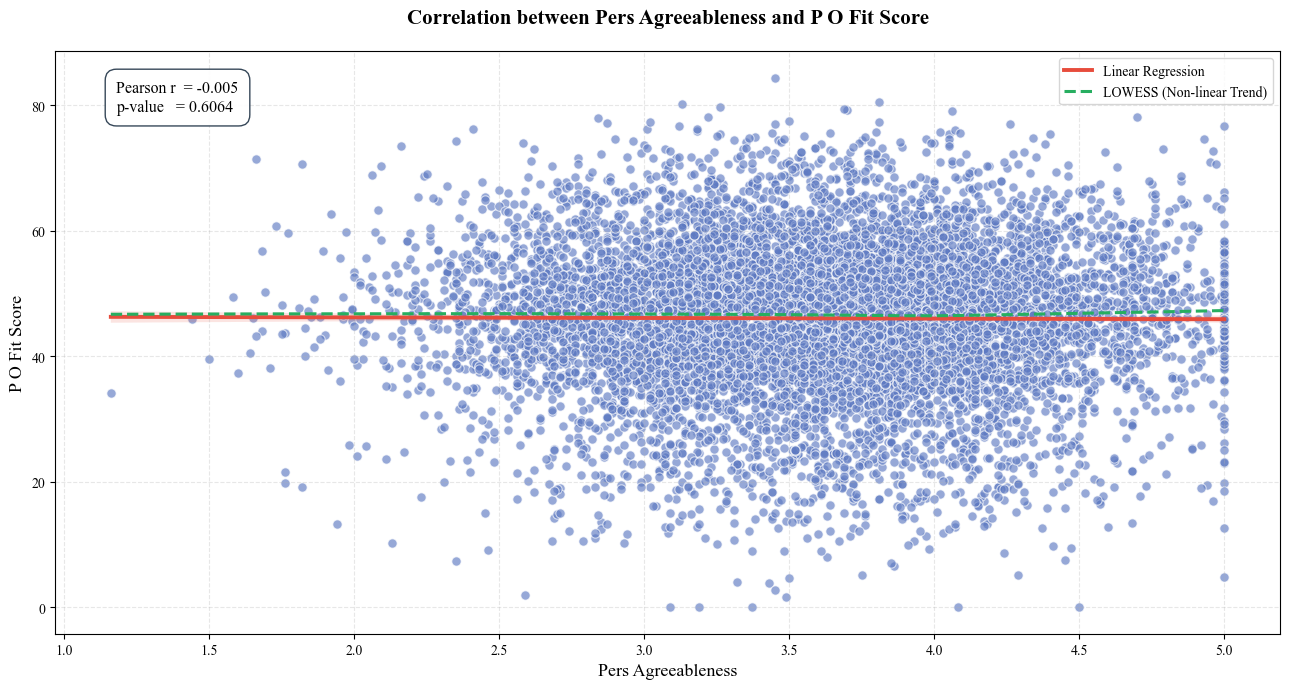

In [14]:
plot_professional_scatter(
    data=data, 
    x_col='pers_agreeableness', 
    y_col='p_o_fit_score'
)

In [42]:
def analyze_agreeableness_friction(
    data, 
    agreeableness_threshold: float = 2.6, 
    fit_score_threshold: float = 45.0
):
    """
    Analyze employees with Low Agreeableness (low cooperation/empathy) 
    who have Low P-O Fit Scores to discover where interpersonal friction is highest.
    """
    # Filter for low cooperation individuals who ended up with low fit scores
    filtered = data[
        (data['p_o_fit_score'] <= fit_score_threshold) & 
        (data['pers_agreeableness'] < agreeableness_threshold)
    ]
    
    total_filtered = len(filtered)
    total_original = len(data)
    percentage = (total_filtered / total_original * 100) if total_original > 0 else 0

    # Dynamic Header using Rich Panel
    console.print(Panel(
        f"[bold #16A085]Low Agreeableness & Team Friction Analysis[/bold #16A085]\n"
        f"Criteria → Agreeableness < {agreeableness_threshold}  |  P-O Fit Score ≤ {fit_score_threshold}\n"
        f"Total Frictional Employees: [bold]{total_filtered}[/bold]  "
        f"([bold]{percentage:.1f}%[/bold] of dataset)",
        title="🤝 TEAM COHESION RISK REPORT",
        border_style="#16A085"
    ))

    # Inner function to generate the Rich tables
    def print_percentage_table(column_name: str, title: str):
        if column_name not in filtered.columns:
            console.print(f"[red]Column '{column_name}' not found![/red]")
            return
            
        vc = filtered[column_name].value_counts()
        percentages = (vc / total_filtered * 100).round(2)
        
        table = Table(
            title=title,
            title_style="bold #D35400",
            box=ROUNDED,
            header_style="bold #D35400"
        )
        
        table.add_column("Category", style="bold", no_wrap=True)
        table.add_column("Count", justify="right")
        table.add_column("Percentage", justify="right")
        table.add_column("Bar (Visual)", justify="left", width=35)
        
        for value, count in vc.items():
            pct = percentages[value]
            bar = "█" * int(pct / 3) + "░" * (30 - int(pct / 3))
            
            table.add_row(
                str(value),
                f"{count:,}",
                f"{pct}%",
                f"[#1ABC9C]{bar}[/#1ABC9C]"
            )
        
        console.print(table)
        console.print()

    # Display results for Leadership Style (Very important for managing stubborn/critical people)
    print_percentage_table(
        'manager_leadership_style', 
        "🔹 Leadership Styles Managing these Low-Cooperation Employees"
    )
    
    # Display results for Department
    print_percentage_table(
        'department', 
        "🔹 Department Distribution (Where does low agreeableness cause low fit?)"
    )


analyze_agreeableness_friction(data)

╭───────────────────────────────────────── 🤝 TEAM COHESION RISK REPORT ──────────────────────────────────────────╮
│ Low Agreeableness & Team Friction Analysis                                                                      │
│ Criteria → Agreeableness < 2.6  |  P-O Fit Score ≤ 45.0                                                         │
│ Total Frictional Employees: 199  (2.0% of dataset)                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

              🔹 Leadership Styles Managing these Low-Cooperation Employees              
╭────────────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│ Category                   │ Count │ Percentage │ Bar (Visual)                        │
├────────────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│ Democratic                 │    98 │     49.25% │ ████████████████░░░░░░░░░░░░░░      │
│ Autocratic/Micromanagement │    60 │     30.15% │ ██████████░░░░░░░░░░░░░░░░░░░░      │
│ Supportive                 │    41 │      20.6% │ ██████░░░░░░░░░░░░░░░░░░░░░░░░      │
╰────────────────────────────┴───────┴────────────┴─────────────────────────────────────╯

    🔹 Department Distribution (Where does low agreeableness cause low fit?)     
╭────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│ Category           │ Count │ Percentage │ Bar (Visual)                        │
├────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│ Sales              │    53 │     26.63% │ ████████░░░░░░░░░░░░░░░░░░░░░░      │
│ Engineering        │    46 │     23.12% │ ███████░░░░░░░░░░░░░░░░░░░░░░░      │
│ Data Science       │    31 │     15.58% │ █████░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Product Management │    30 │     15.08% │ █████░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Marketing          │    23 │     11.56% │ ███░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ HR                 │    16 │      8.04% │ ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
╰────────────────────┴───────┴────────────┴─────────────────────────────────────╯

<div class="pd-index-animation">
     Neuroticism
</div>
<style>
.pd-index-animation {
  font-family: 'Courier New', monospace;
  font-size: 1.8em;
  color: rgb(156, 174, 212); /* رنگ مشابه تم pandas در VS Code */
  background: #1e1e1e;
  padding: 16px 20px;
  border-radius: 8px;
  display: inline-block;
  opacity: 0;
  transform: scale(0.8);
  animation: fadeInScale 1.2s cubic-bezier(0.34, 1.56, 0.64, 1) forwards;
  letter-spacing: 1px;
}
@keyframes fadeInScale {
  to {
    opacity: 1;
    transform: scale(1);
  }
}
</style>

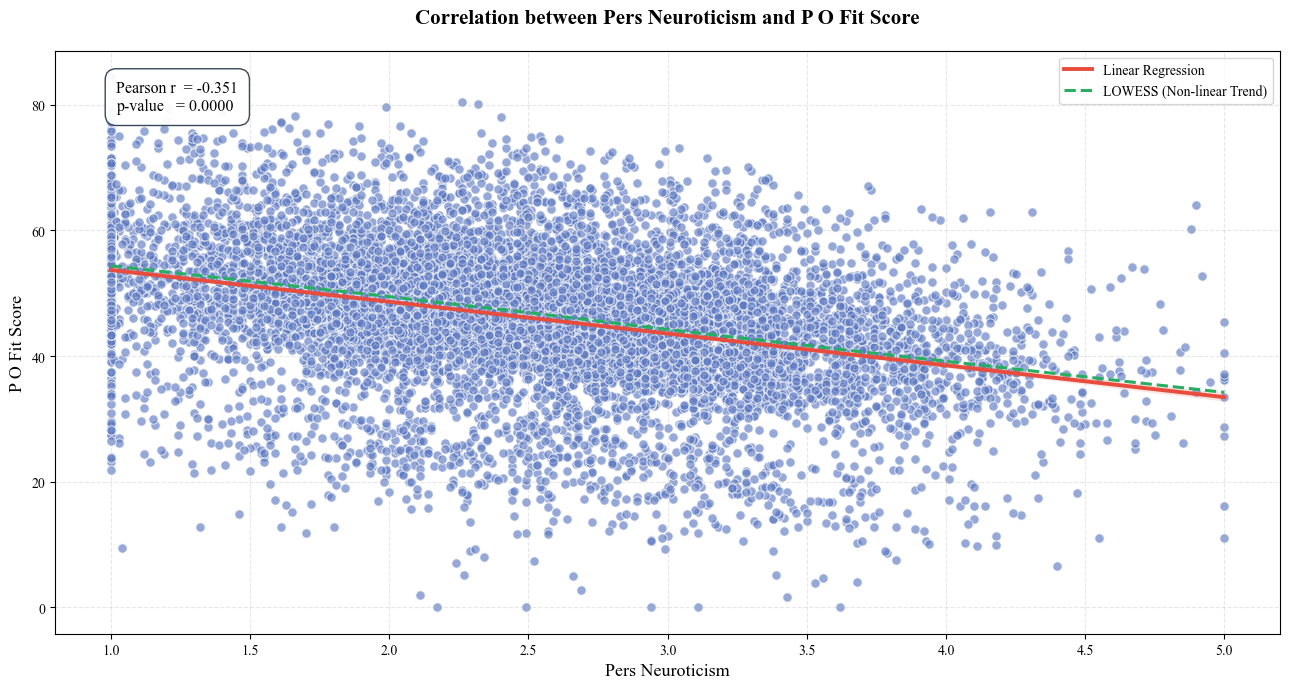

In [15]:
plot_professional_scatter(
    data=data, 
    x_col='pers_neuroticism', 
    y_col='p_o_fit_score'
)

In [46]:
def analyze_neuroticism_stress_triggers(
    data, 
    neuroticism_threshold: float = 4.0, 
    fit_score_threshold: float = 40.0
):
    """
    Analyze highly sensitive employees (High Neuroticism) who have Low P-O Fit Scores
    to identify the environmental stress triggers (Departments or Leadership Styles).
    """
    # Filter for high anxiety/sensitivity individuals who ended up with low fit scores
    filtered = data[
        (data['p_o_fit_score'] <= fit_score_threshold) & 
        (data['pers_neuroticism'] > neuroticism_threshold)
    ]
    
    total_filtered = len(filtered)
    total_original = len(data)
    percentage = (total_filtered / total_original * 100) if total_original > 0 else 0

    # Dynamic Header using Rich Panel
    console.print(Panel(
        f"[bold #C0392B]High Neuroticism & Workplace Stress Analysis[/bold #C0392B]\n"
        f"Criteria → Neuroticism > {neuroticism_threshold}  |  P-O Fit Score ≤ {fit_score_threshold}\n"
        f"Total Stressed Employees: [bold]{total_filtered}[/bold]  "
        f"([bold]{percentage:.1f}%[/bold] of dataset)",
        title="🧠 BURNOUT & STRESS RISK REPORT",
        border_style="#C0392B"
    ))

    # Inner function to generate the Rich tables
    def print_percentage_table(column_name: str, title: str):
        if column_name not in filtered.columns:
            console.print(f"[red]Column '{column_name}' not found![/red]")
            return
            
        vc = filtered[column_name].value_counts()
        percentages = (vc / total_filtered * 100).round(2)
        
        table = Table(
            title=title,
            title_style="bold #7CEBF5",
            box=ROUNDED,
            header_style="bold #4E73E3"
        )
        
        table.add_column("Category", style="bold", no_wrap=True)
        table.add_column("Count", justify="right")
        table.add_column("Percentage", justify="right")
        table.add_column("Bar (Visual)", justify="left", width=35)
        
        for value, count in vc.items():
            pct = percentages[value]
            bar = "█" * int(pct / 3) + "░" * (30 - int(pct / 3))
            
            table.add_row(
                str(value),
                f"{count:,}",
                f"{pct}%",
                f"[#E74C3C]{bar}[/#E74C3C]"
            )
        
        console.print(table)
        console.print()

    # Display results for Leadership Style (Crucial component for psychological safety)
    print_percentage_table(
        'manager_leadership_style', 
        "🔹 Management Leadership Styles associated with High Stress"
    )
    
    # Display results for Department (Which roles are environment-heavy?)
    print_percentage_table(
        'department', 
        "🔹 Department Distribution for Highly Sensitive Employees"
    )

 
analyze_neuroticism_stress_triggers(data)

╭──────────────────────────────────────── 🧠 BURNOUT & STRESS RISK REPORT ────────────────────────────────────────╮
│ High Neuroticism & Workplace Stress Analysis                                                                    │
│ Criteria → Neuroticism > 4.0  |  P-O Fit Score ≤ 40.0                                                           │
│ Total Stressed Employees: 195  (1.9% of dataset)                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

               🔹 Management Leadership Styles associated with High Stress               
╭────────────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│ Category                   │ Count │ Percentage │ Bar (Visual)                        │
├────────────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│ Democratic                 │    91 │     46.67% │ ███████████████░░░░░░░░░░░░░░░      │
│ Autocratic/Micromanagement │    55 │     28.21% │ █████████░░░░░░░░░░░░░░░░░░░░░      │
│ Supportive                 │    49 │     25.13% │ ████████░░░░░░░░░░░░░░░░░░░░░░      │
╰────────────────────────────┴───────┴────────────┴─────────────────────────────────────╯

            🔹 Department Distribution for Highly Sensitive Employees            
╭────────────────────┬───────┬────────────┬─────────────────────────────────────╮
│ Category           │ Count │ Percentage │ Bar (Visual)                        │
├────────────────────┼───────┼────────────┼─────────────────────────────────────┤
│ Engineering        │    53 │     27.18% │ █████████░░░░░░░░░░░░░░░░░░░░░      │
│ Sales              │    40 │     20.51% │ ██████░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Marketing          │    36 │     18.46% │ ██████░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Product Management │    26 │     13.33% │ ████░░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ Data Science       │    24 │     12.31% │ ████░░░░░░░░░░░░░░░░░░░░░░░░░░      │
│ HR                 │    16 │      8.21% │ ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░      │
╰────────────────────┴───────┴────────────┴─────────────────────────────────────╯

### Another feature

In [52]:
console = Console()

def compare_po_fit_groups(data):
    """
    Comprehensive comparison between High and Low P-O Fit Score groups
    """
    # Define two groups
    high_fit = data[data['p_o_fit_score'] >= 50]
    low_fit = data[data['p_o_fit_score'] <= 70]
    
    console.print(Panel(
        "[bold #2C9B5E]High P-O Fit[/bold #2C9B5E] (Score ≥ 50)  vs  "
        "[bold #E74C3C]Low P-O Fit[/bold #E74C3C] (Score ≤ 70)",
        title="📊 P-O FIT SCORE GROUP COMPARISON",
        border_style="#6A5ACD"
    ))
    
    def create_comparison_table(variable: str, title: str):
        """Create beautiful comparison table for a variable"""
        
        high_stats = high_fit[variable].agg(['mean', 'median', 'min', 'max', 'std', 'count'])
        low_stats = low_fit[variable].agg(['mean', 'median', 'min', 'max', 'std', 'count'])
        
        table = Table(
            title=title,
            title_style="bold #6A5ACD",
            box=ROUNDED,
            header_style="bold #6A5ACD"
        )
        
        table.add_column("Metric", style="bold", width=18)
        table.add_column("High Fit (≥50)", justify="right", style="#2C9B5E")
        table.add_column("Low Fit (≤70)", justify="right", style="#E74C3C")
        table.add_column("Difference", justify="right")
        
        metrics = ['mean', 'median', 'min', 'max', 'std']
        metric_labels = {
            'mean': 'Mean',
            'median': 'Median',
            'min': 'Minimum',
            'max': 'Maximum',
            'std': 'Std Deviation'
        }
        
        for m in metrics:
            high_val = high_stats[m]
            low_val = low_stats[m]
            diff = high_val - low_val
            
            # Color the difference
            diff_color = "green" if diff > 0 else "red" if diff < 0 else "white"
            
            table.add_row(
                metric_labels[m],
                f"{high_val:.2f}",
                f"{low_val:.2f}",
                f"[{diff_color}]{diff:+.2f}[/{diff_color}]"
            )
        
        # Add sample size
        table.add_row("Sample Size", 
                     f"{high_stats['count']:,}", 
                     f"{low_stats['count']:,}", 
                     "")
        
        console.print(table)
        console.print()


    
    create_comparison_table(
        'years_at_company', 
        "🕒 Years at Company Comparison"
    )
    
    create_comparison_table(
        'work_flexibility_preference', 
        "🔄 Work Flexibility Preference Comparison"
    )

compare_po_fit_groups(data)

╭─────────────────────────────────────── 📊 P-O FIT SCORE GROUP COMPARISON ───────────────────────────────────────╮
│ High P-O Fit (Score ≥ 50)  vs  Low P-O Fit (Score ≤ 70)                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                   🕒 Years at Company Comparison                   
╭────────────────────┬────────────────┬───────────────┬────────────╮
│ Metric             │ High Fit (≥50) │ Low Fit (≤70) │ Difference │
├────────────────────┼────────────────┼───────────────┼────────────┤
│ Mean               │           3.90 │          3.99 │      -0.09 │
│ Median             │           2.70 │          2.80 │      -0.10 │
│ Minimum            │           0.50 │          0.50 │      +0.00 │
│ Maximum            │          20.00 │         20.00 │      +0.00 │
│ Std Deviation      │           3.74 │          3.84 │      -0.10 │
│ Sample Size        │        3,596.0 │       9,844.0 │            │
╰────────────────────┴────────────────┴───────────────┴────────────╯

             🔄 Work Flexibility Preference Comparison              
╭────────────────────┬────────────────┬───────────────┬────────────╮
│ Metric             │ High Fit (≥50) │ Low Fit (≤70) │ Difference │
├────────────────────┼────────────────┼───────────────┼────────────┤
│ Mean               │           3.51 │          3.48 │      +0.03 │
│ Median             │           4.00 │          4.00 │      +0.00 │
│ Minimum            │           1.00 │          1.00 │      +0.00 │
│ Maximum            │           5.00 │          5.00 │      +0.00 │
│ Std Deviation      │           1.16 │          1.16 │      -0.00 │
│ Sample Size        │        3,596.0 │       9,844.0 │            │
╰────────────────────┴────────────────┴───────────────┴────────────╯

### Model

In [60]:
# Create a copy of the original data to avoid modifying it
df_ml = data.copy()

# Define target variable and features
target_col = 'p_o_fit_score'

feature_cols = [
    'pers_openness', 
    'pers_conscientiousness', 
    'pers_extraversion', 
    'pers_agreeableness', 
    'pers_neuroticism', 
    'department', 
    'manager_leadership_style'
]

 
X = df_ml[feature_cols]
y = df_ml[target_col]

# Encode categorical variables (One-Hot Encoding)
# drop_first=False keeps all categories for better interpretability
X_encoded = pd.get_dummies(
    X, 
    columns=['department', 'manager_leadership_style'], 
    drop_first=False
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.2, 
    random_state=42
)

 

console = Console()

console.print(Panel(
    f"Total Dataset Size: [bold]{len(df_ml)}[/bold]\n"
    f"Training Set Size: [bold]{len(X_train)}[/bold] (80%)\n"
    f"Testing Set Size: [bold]{len(X_test)}[/bold] (20%)\n"
    f"Total Features after Encoding: [bold]{X_encoded.shape[1]}[/bold]",
    title="⚙️ DATA PREPARATION COMPLETE",
    border_style="red"
))

╭────────────────────────────────────────── ⚙️ DATA PREPARATION COMPLETE ──────────────────────────────────────────╮
│ Total Dataset Size: 10000                                                                                       │
│ Training Set Size: 8000 (80%)                                                                                   │
│ Testing Set Size: 2000 (20%)                                                                                    │
│ Total Features after Encoding: 14                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [59]:
# 1. Define and train the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200, 
    max_depth=12, 
    random_state=42, 
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# 2. Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# 3. Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

 

table = Table(
    title="🏆 Model Evaluation Metrics (Test Set)", 
    header_style="red"
)

table.add_column("Metric", style="bold")
table.add_column("Value", justify="right")
table.add_column("Interpretation", style="italic")

table.add_row(
    "R² Score", 
    f"{r2:.4f}", 
    "Proportion of variance explained by the model (closer to 1 is better)"
)

table.add_row(
    "MAE (Mean Absolute Error)", 
    f"{mae:.2f}", 
    "Average deviation of predictions from actual P-O Fit scores"
)

table.add_row(
    "RMSE (Root Mean Squared Error)", 
    f"{rmse:.2f}", 
    "Penalizes larger errors more heavily"
)

console.print(table)

                                      🏆 Model Evaluation Metrics (Test Set)                                       
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric                         ┃  Value ┃ Interpretation                                                        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ R² Score                       │ 0.7892 │ Proportion of variance explained by the model (closer to 1 is better) │
│ MAE (Mean Absolute Error)      │   4.01 │ Average deviation of predictions from actual P-O Fit scores           │
│ RMSE (Root Mean Squared Error) │   5.16 │ Penalizes larger errors more heavily                                  │
└────────────────────────────────┴────────┴───────────────────────────────────────────────────────────────────────┘

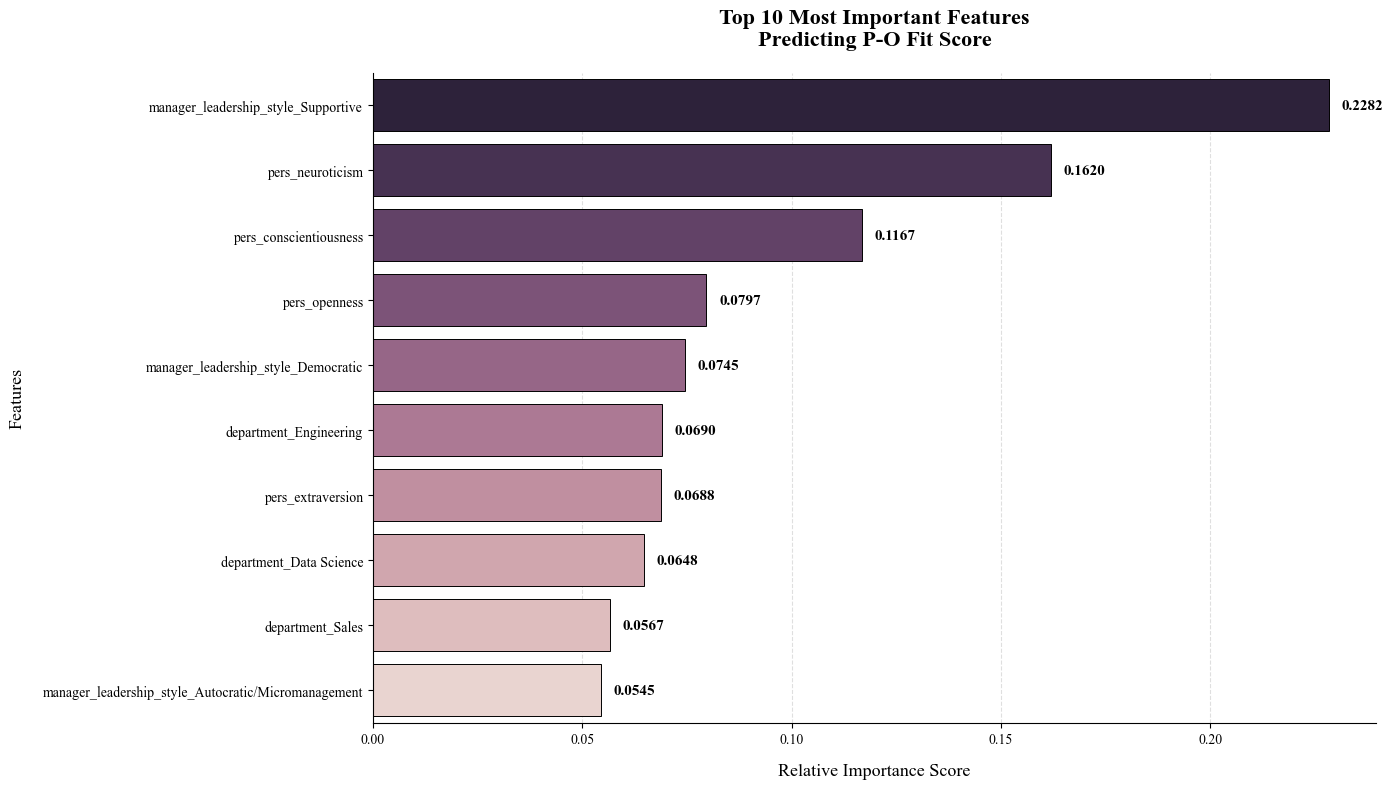

In [64]:
# Extract feature importances from the trained Random Forest model
importances = rf_model.feature_importances_
feature_names = X_encoded.columns

# Create a DataFrame for better visualization and sorting
df_importance = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
})

# Sort by importance and select top 10 features
df_importance = df_importance.sort_values(
    by='Importance', 
    ascending=False
).head(10)

 

plt.figure(figsize=(14, 8))

 
palette = sns.cubehelix_palette(as_cmap=False, n_colors=len(df_importance), reverse=True)

ax = sns.barplot(
    data=df_importance,
    x='Importance',
    y='Feature',
    hue='Feature',           
    palette=palette,
    legend=False,             
    edgecolor='black',
    linewidth=0.7
)

# Add value labels on bars
for i, v in enumerate(df_importance['Importance']):
    ax.text(
        v + 0.003, i, f"{v:.4f}", 
        va='center', 
        fontsize=11, 
        fontweight='bold',
        color='black'
    )

# Title and labels
plt.title('Top 10 Most Important Features\nPredicting P-O Fit Score', 
          fontsize=16, 
          fontweight='bold', 
          pad=20)

plt.xlabel('Relative Importance Score', fontsize=13, labelpad=12)
plt.ylabel('Features', fontsize=13, labelpad=12)

# Grid and style improvements
plt.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

sns.despine(left=False, bottom=False, right=True, top=True)

plt.tight_layout()
plt.show()

In [65]:
import joblib

 
model_filename = 'random_forest_fit_model.pkl'
joblib.dump(rf_model, model_filename)

columns_filename = 'model_features_columns.pkl'
joblib.dump(X_encoded.columns.tolist(), columns_filename)

print("🎉 Model and Feature Columns saved successfully!")
print(f"📁 Saved: {model_filename}")
print(f"📁 Saved: {columns_filename}")

🎉 Model and Feature Columns saved successfully!
📁 Saved: random_forest_fit_model.pkl
📁 Saved: model_features_columns.pkl
